# 7. Canopy structure

Vertical profiles and plant area from a point cloud, and gap fraction from
pulse data. For the rigorous ray-traced version see notebook 9.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set

from sylva import canopy, filters, ground

cloud = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.05)
dtm = ground.make_dtm(ground.classify_ground_pmf(cloud), 0.5, bounds=(0, 0, 20, 20))
cloud = ground.normalize_height(cloud, dtm)

The data: a 20 x 20 m tile of the TERN [Litchfield Savanna
SuperSite](https://www.tern.org.au) plot in the Northern Territory, scanned in
2021 with a RIEGL VZ-2000i from many positions and registered into one cloud.
`litch_tile.laz` holds the echoes inside the tile thinned to 5 cm, with
`classification` (2 ground, 4 vegetation) and `intensity`;
`litch_tile_shots.parquet` holds every 40th pulse, clipped to the tile, misses
included. The plot data are TERN's; `make_litch_subset.py` cuts the tile.

## Occupancy and the contact-frequency profile

`voxelize` counts points per voxel. `pad_profile_voxel` turns the fraction of
occupied voxels per layer into plant area density (a simplified Hosoi & Omasa
2006, assuming vertical beams and G = 0.5). Both ignore occlusion and both
depend on the point density, so they describe the cloud as much as the canopy
-- pulse data (notebook 9) is what measures the canopy.

voxel grid (nx, ny, nz): (81, 81, 80)
PAI from voxel occupancy: 4.47   (the ray-traced plot value for Litchfield is 1.4, see the canopy benchmark)


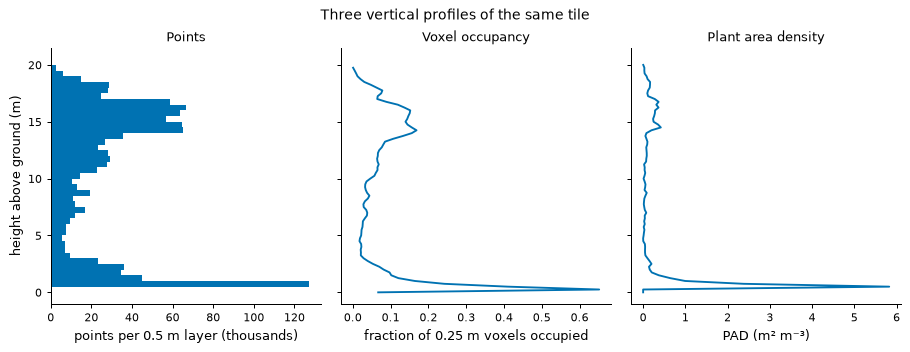

In [2]:
veg = cloud[cloud.attrs["height"] > 0.5]
grid = canopy.voxelize(veg, 0.25)
z, pad = canopy.pad_profile_voxel(veg, voxel_size=0.25)
print("voxel grid (nx, ny, nz):", grid.shape)
print("PAI from voxel occupancy:", round(float(np.nansum(pad) * 0.25), 2),
      "  (the ray-traced plot value for Litchfield is 1.4, see the canopy benchmark)")

hb, counts = canopy.vertical_profile(veg, bin_size=0.5)
fig, ax = plt.subplots(1, 3, figsize=(10, 3.8), sharey=True)
ax[0].barh(hb, np.asarray(counts) / 1000, height=0.5, align="edge", color="C0")
ax[0].set(title="Points", xlabel="points per 0.5 m layer (thousands)", ylabel="height above ground (m)")
ax[1].plot(grid.vertical_profile(), grid.z_levels() - grid.origin[2])
ax[1].set(title="Voxel occupancy", xlabel="fraction of 0.25 m voxels occupied")
ax[2].plot(pad, z)
ax[2].set(title="Plant area density", xlabel="PAD (m² m⁻³)")
fig.suptitle("Three vertical profiles of the same tile");

The savanna's structure shows in all three: a dense grass and shrub
layer below 2 m, a sparse middle, and a canopy from 8 m to 20 m. The point
profile exaggerates the lower layers, which are metres from the scanners; the
occupancy profile is flatter because a voxel counts once however many points
it holds.

## Canopy cover and the CHM

In [3]:
chm = ground.make_chm(cloud, resolution=0.5)
for h in (0.5, 2.0, 5.0, 10.0):
    print(f"cover above {h:4.1f} m: {canopy.canopy_cover(chm.data, h):.2f}")

cover above  0.5 m: 0.96
cover above  2.0 m: 0.68
cover above  5.0 m: 0.62
cover above 10.0 m: 0.57


## Gap fraction from pulses

Gap fraction inverts the fraction of pulses that got through at each zenith
angle, so it needs pulses with their scanner origins. The tile's pulse file
cannot serve here: its rays were clipped at the tile boundary, so their origins
sit on the tile edge rather than at a scanner (notebook 8). This part uses a
synthetic plot instead, where the leaf area is known -- see
[Pulse data](../guide/pulses.md) and the [canopy
benchmark](../benchmarks/canopy.md) for whole plots read from RIEGL `.rxp`,
where Sylva's profiles match pylidar-tls-canopy to within 4 %.

The plot (`synthetic.plot`) is 50 m square, so that pulses at 57.5 degrees
reach the top of the canopy before they leave it: 125 broadleaf and
eucalypt trees with shrubs, grass and dead wood, scanned once from its centre
with the model of a RIEGL VZ-400, which sees from 30 degrees zenith down.
The truth is the trees' leaf area, from the leaves the generator placed.

Shots(n_shots=3,600,000, n_echoes=3,075,804) - 22% of pulses returned nothing
true leaf area index of the trees: 2.90 (plus bark and understorey)


effective PAI (hinge, 57.5 deg): 1.56


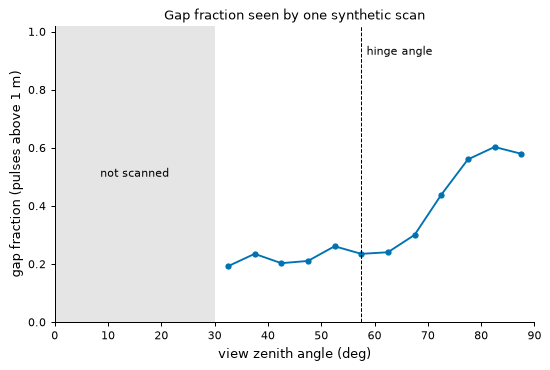

In [4]:
p = synthetic.plot(size=50, density=500, archetypes={"broadleaf": 1, "eucalypt": 1}, seed=1)
x, y = 25.0, 25.0
shots = synthetic.scan(p.points, origin=(x, y, 1.5 + p.ground_height(x, y)), resolution_deg=0.1,
                       scanner="vz400", range_noise=0.005, seed=0)
print(shots, f"- {np.mean(shots.echo_count == 0):.0%} of pulses returned nothing")
print(f"true leaf area index of the trees: {p.trees['leaf_area'].sum() / 50**2:.2f} (plus bark and understorey)")
echoes = shots.echo_xyz()
echo_height = echoes[:, 2] - p.ground_height(echoes[:, 0], echoes[:, 1])
zen, gap = canopy.gap_fraction_zenith(shots, echo_height, min_height=1.0, zenith_edges=np.arange(30, 95, 5.0))
print(f"effective PAI (hinge, 57.5 deg): {canopy.lai_from_gap_fraction(zen, gap, 'hinge'):.2f}")
fig, ax = plt.subplots()
ax.plot(zen, gap, "o-")
ax.axvline(57.5, c="k", ls="--", lw=0.8)
ax.text(58.5, 0.92, "hinge angle", fontsize=8.5)
ax.axvspan(0, 30, color=CONTEXT, alpha=0.5, lw=0)
ax.text(15, 0.5, "not scanned", ha="center", fontsize=8.5)
ax.set(xlabel="view zenith angle (deg)", ylabel="gap fraction (pulses above 1 m)", ylim=(0, 1.02), xlim=(0, 90),
       title="Gap fraction seen by one synthetic scan");

The effective PAI lands at about half the trees' leaf area index, and
that is the point of the exercise: the leaves are clumped into crowns,
which lets more pulses through than the same leaf area spread evenly, so an
*effective* PAI is a lower bound on the real one. A clumping correction, or
the ray-traced voxels of notebook 9, recover more of it. Miller's integral
is not used here: it needs every zenith ring from 0 to 90 degrees, and the
scanner sees none above 30. The rise beyond 70 degrees is the edge of the
plot: pulses that close to horizontal leave it before they reach the
canopy.